# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Botron, Christan Jake
- _Student No._: 2024-10168
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![Wave Interference](./figures/prob1_wave-interference.png)
*Figure 1. Simulated 2D wave interference patterns from two (left) and four (right) point sources*

Figure 1 illustrates the principle of linear superposition in a 2D scalar field. The left plot demonstrates the classic fringes and hyperbolic bands created by the constructive and destructive interference of the waves of two point sources located along the x-axis. The right panel displays a more complex geometry generated by four symmetrically arranged sources, which produces a sort-of checkerboard/flower-looking interference pattern near the origin. The scalar amplitude at each spatial coordinate is mapped to a color gradient, highlighting the peaks and troughs of the combined waves.

### Problem 2 

While my custom function successfully computed the expected results for the matrix multiplication of a 2x2 and 2x4 matrix, it will definitely struggle with matrices of high dimensions. For those kinds of matrices, the @ operator (especially alongside libraries like NumPy) is vastly preferred over custom pure Python scripts as those computations are better handled by highly optimized, pre-compiled C or Fortran routines. These have better hardware-level vectorization and superior memory management (and, of course, more efficient coding), unlike, for example, my code which requires Python to evaluate nested loops sequentially, creating severe performance bottlenecks. More broadly, writing idiomatic, or "Pythonic," code offers several significant benefits for computational programming, the most important of which being efficiency. Furthermore, idiomatic code is inherently cleaner, more concise, and more aligned with standard scientific computing practices. 

### Other comments
While I do have experience in coding, this exercise reminded me that I should study to regain the knowledge previously imparted to me by my professor in high school. Looking at the codes now, they do not seem complicated at all. However, while I was writing them during class, I have completely forgotten some very basic stuff, which led me to finish this exercise later than I had liked to. Regardless, I had fun, and actually learned something new, especially regarding list comprehension. I will definitely be studying that so that my codes wont be very long.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

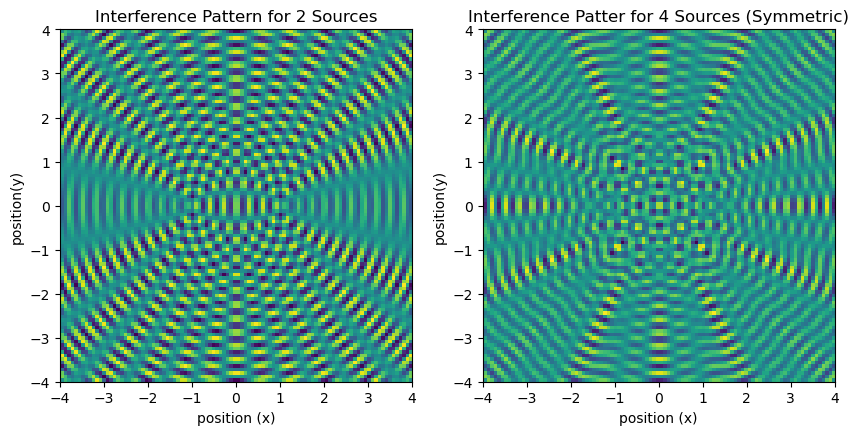

In [13]:
import matplotlib.pyplot as plt
from math import pi
from math import sin
from math import sqrt

#given
A = 1
k = 2*pi / 0.3
#cartesian locations of point sources
r_0 = (-1,0) #-x axis
r_1 = (1,0)  #+x axis
r_2 = (0,-1) #-y axis
r_3 = (0,1)  #+y axis
num_points = 100 #arbitrary

def linspace(start, stop, incr): #caveman version of np.linspace() (since we can't use np for now); generate grid
    step = (stop-start)/(incr-1)
    return [start + i*step for i in range(incr)]

X = linspace(-4,4,num_points)
Y = linspace(-4,4,num_points) #or X.copy()

#wave amplitude at specific coordinates (W(r) value per point in our grid)
amplitude_matrix_2src = [] 
amplitude_matrix_4src = []

#we calculate W(r) by slicing the matrix horizontally until we fill the entire vertical field, hence the nested for-loops
for y in Y:
    W_horizontal_2src = []
    W_horizontal_4src = []
    for x in X:
        #distance of point to wave source
        r0 = sqrt((x-r_0[0])**2 + (y-r_0[1])**2) 
        r1 = sqrt((x-r_1[0])**2 + (y-r_1[1])**2)
        r2 = sqrt((x-r_2[0])**2 + (y-r_2[1])**2)
        r3 = sqrt((x-r_3[0])**2 + (y-r_3[1])**2)

        # W(r) calculation per horizontal 
        W_horizontal_2src.append(A*sin(k*r0) + A*sin(k*r1))
        W_horizontal_4src.append(A*sin(k*r0) + A*sin(k*r1) + A*sin(k*r2) + A*sin(k*r3))

    #appending the W(r) calculation per horizontal to a list-of-lists, building our matrix ([[row1], [row2], [row3], ...)
    amplitude_matrix_2src.append(W_horizontal_2src)
    amplitude_matrix_4src.append(W_horizontal_4src)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(amplitude_matrix_2src, extent=[-4, 4, -4, 4], origin="lower")
ax1.set_title("Interference Pattern for 2 Sources")
ax1.set_xlabel("position (x)")
ax1.set_ylabel("position(y)")

ax2.imshow(amplitude_matrix_4src, extent=[-4, 4, -4, 4], origin="lower")
ax2.set_title("Interference Patter for 4 Sources (Symmetric)")
ax2.set_xlabel("position (x)")
ax2.set_ylabel("position(y)")

plt.show()

#### Problem 1 code summary

My code models 2D wave interference patterns by calculating linear superpositions of sinusoidal waves emitted from discrete point sources. My thought process was getting the W(r) values in each horizontal slice point by point and then stacking those lists of values. The nested loop in my code helped me do just that, allowing me to form a sort-of map (or scalar field) without using explicit (x,y) coordinates. I then plotted all those to get the interference patterns above.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [14]:
import random
import numpy as np
number = random.randint(1, 9)
number

7

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [15]:
def random_integer_matrix(nrows, ncols):
    row_list = []
    for i in range(nrows):
        col_list = [random.randint(1,9) for _ in range(ncols)]
        row_list.append(col_list)
    return row_list
    
random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[6, 9, 3, 4], [1, 6, 3, 6], [8, 6, 8, 2]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [16]:
#SET TEST ARRAY#
working_array_b = random_integer_matrix(2,3)
print("working array:", working_array_b)

working array: [[8, 6, 9], [6, 9, 5]]


In [17]:
def scalar_product_easy(list1, list2): #easy mode (using zip() function)
    if len(list1) != len(list2): #length of both lists must be equal for us to do scalar product
        print("Invalid input!")
    else:
        return sum(x_n*y_n for x_n, y_n in zip(list1, list2)) #takes the nth items of each list using the zip() function and multiply them. after that, we sum the products using the sum() function
print("Scalar Product:", scalar_product_easy(working_array_b[0], working_array_b[1]))

Scalar Product: 147


In [18]:
#using loops#
def scalar_product(list1, list2):
    if len(list1) != len(list2): #length of both lists must be equal for us to do scalar product
        print("Invalid input!")
    else:
        sum = 0
        for i in range(len(list1)): #goes thru the items in each list. given that len(list1) = len(list2), we can use either for the range function
            sum += list1[i]*list2[i] #multiplies the (i-1)th items of both lists and add their value to the sum. running this loop sums all of the other products.
        return sum
print("Scalar Product:", scalar_product(working_array_b[0], working_array_b[1]))

Scalar Product: 147


c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [19]:
#SET TEST MATRIX#
working_matrix_c = random_integer_matrix(3,4) #random 3x4 matrix using the random matrix maker in part a
print("working matrix:", working_matrix_c)

working matrix: [[5, 5, 5, 2], [7, 7, 4, 5], [3, 2, 2, 2]]


In [20]:
def transpose_matrix(orig_matrix):
    return [list(item) for item in zip(*orig_matrix)] 
    #zip() function mixes all of the nth items into 1 tuple. the list comprehension line transforms the tuple-of-tuples into list-of-lists
    
transpose_matrix(working_matrix_c)

[[5, 7, 3], [5, 7, 2], [5, 4, 2], [2, 5, 2]]

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [21]:
#SET TEST MATRICES#
left_matrix_d = random_integer_matrix(2,2)
right_matrix_d = random_integer_matrix(2,4)
print("left matrix:", left_matrix_d)
print("right matrix:", right_matrix_d)

left matrix: [[1, 7], [4, 3]]
right matrix: [[4, 3, 1, 8], [1, 1, 2, 6]]


In [22]:
def matrix_multiply(left_matrix, right_matrix):
    if len(left_matrix[0]) != len(right_matrix): # num_col_left = num_rows_right for valid matrix multiplication (must have the same "height")
        print("Invalid inputs!")
    else:
        right_matrix_transpose = transpose_matrix(right_matrix)
        col_list= []
        for i in range(len(left_matrix)):
            row_list = []
            for j in range(len(right_matrix_transpose)): #nested loop; we basically iterate thru the right columns while keeping the left row fixed, allowing us to take the row list.
                row_list.append(scalar_product(left_matrix[i],  right_matrix_transpose[j])) #takes the dot product of the left matrix with the transpose of the right matrix and adds to the row list
            col_list.append(row_list) #appends the row list to the column list (e.g., we take the list for the first row, then the second row, then we append them to a list-of-lists which is the col_list in this case
        return col_list
     
        
matrix_multiply(left_matrix_d, right_matrix_d)


[[11, 10, 15, 50], [19, 15, 10, 50]]

#### Problem 2 code summary
#### Yap Session:

Problems a-c were a setup for problem d, which is matrix multiplication. 

For part a, which is the function for creating m x n matrices of arbitrary size (determined by the user), I wrote it in a way that is straightforward in terms of reading the code. It was intuitive for me to think of it as building the matrix row by row, so I generated an m-sized lists that would act as the "rows." Then, I appended those lists into a list-of-lists, which builds the matrix.

For part b, it was straightforward as I just used the a for-loop (or the zip() function) to iterate through each position in the two lists. I then multiplied the same-positioned items and summed up their value with the products of other same-positioned items.

For part c, I just used the zip() function as putting the same-positioned items of the different row lists into a single list essentially acts as a transpose. (reference: https://www.w3schools.com/python/trypython.asp?filename=demo_ref_zip)

For part d, I just mixed everything. Matrix multiplication is multiplying the rows of the left matrix with the columns of the right matrix, which is essentially just the dot product of the left matrix with the transpose of the right matrix. Hence, in my code, I just got the dot product of the row and column lists and arranged them in a list-of-lists to form the final matrix.

#### Actual summary:

The final script performs matrix multiplication for matrices of arbitrary sizes (part a) by calculating the dot product (part b) of the left matrix's rows against the right matrix's columns (part c). Transposing the right matrix first by utilizing Python's zip() function was an intentional (and guided) choice to align matching elements easily without the long loop codes, making the solution for the transpose a straightforward row by row traversal. My approach prioritized code readability and intuition, and also served as a practice for list comprehension, allowing the final matrix to be built row by row just as I would calculate it by hand.
